## Emerging trends prediction

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/complaints_final.csv').iloc[:,1:]

In [4]:
df['Issue_Category'].value_counts()

Issue_Category
Credit Reporting                  86674
Debt Collection                   65686
Loan Servicing & Repayment        50142
Other                             36649
Billing, Fees & Payments          21895
Account Management                15396
Fraud & Unauthorized Activity      8114
Customer Service & Disclosures     3553
Lending Process & Approval         2521
Name: count, dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df["Year"] = df["Date"].dt.year

issue_year = (
    df.groupby(["Issue_Category", "Year"])
      .size()
      .unstack(fill_value=0)
)

issue_year = issue_year

In [7]:
months = {
    2015: 6.5,
    2016: 12,
    2017: 12,
    2018: 5.5
}

issue_adjusted = issue_year.copy()

for year in issue_adjusted.columns:
    issue_adjusted[year] = issue_adjusted[year] / months[year]

In [8]:
issue_adjusted

Year,2015,2016,2017,2018
Issue_Category,,,,
Account Management,294.769231,378.500000,486.166667,564.363636
"Billing, Fees & Payments",426.923077,491.250000,716.833333,840.545455
Credit Reporting,1106.307692,1223.416667,3421.250000,4317.636364
Customer Service & Disclosures,81.846154,92.500000,104.916667,118.545455
Debt Collection,1515.076923,1560.083333,1965.916667,2459.272727
Fraud & Unauthorized Activity,196.615385,163.666667,292.500000,247.636364
Lending Process & Approval,70.000000,77.000000,69.416667,56.181818
Loan Servicing & Repayment,1350.461538,1518.833333,1502.750000,928.181818
Other,870.769231,975.333333,1049.083333,1217.454545


In [9]:
issue_share = (
    issue_adjusted.div(issue_adjusted.sum(axis=0), axis=1)*100
)

In [10]:
issue_share

Year,2015,2016,2017,2018
Issue_Category,,,,
Account Management,4.985299,5.840524,5.059581,5.249983
"Billing, Fees & Payments",7.220358,7.580336,7.460150,7.819160
Credit Reporting,18.710483,18.878187,35.605259,40.164739
Customer Service & Disclosures,1.384227,1.427341,1.091877,1.102767
Debt Collection,25.623813,24.073193,20.459473,22.877343
Fraud & Unauthorized Activity,3.325267,2.525493,3.044074,2.303633
Lending Process & Approval,1.183878,1.188165,0.722426,0.522630
Loan Servicing & Repayment,22.839747,23.436676,15.639256,8.634396
Other,14.726927,15.050086,10.917905,11.325350


In [11]:
issue_growth = issue_adjusted.pct_change(axis=1).iloc[:,1:]*100
issue_growth

Year,2016,2017,2018
Issue_Category,,,
Account Management,28.405532,28.445619,16.084396
"Billing, Fees & Payments",15.067568,45.920271,17.258143
Credit Reporting,10.585570,179.647163,26.200551
Customer Service & Disclosures,13.016917,13.423423,12.990108
Debt Collection,2.970569,26.013568,25.095472
Fraud & Unauthorized Activity,-16.757955,78.716904,-15.337995
Lending Process & Approval,10.000000,-9.848485,-19.065808
Loan Servicing & Repayment,12.467722,-1.058927,-38.234449
Other,12.008245,7.561517,16.049365


In [12]:
years = len(issue_year.columns)-1

cagr = round((
    (issue_adjusted.iloc[:, -1] /
     issue_adjusted.iloc[:, 0].replace(0,1))
    ** (1/years) - 1
), 3)*100

cagr = (
    cagr.reset_index()
        .rename(columns={0:"CAGR"})
        .sort_values("CAGR", ascending=False)
)

In [ ]:
df

In [13]:
cagr

,Issue_Category,CAGR
2,Credit Reporting,57.4
1,"Billing, Fees & Payments",25.3
0,Account Management,24.2
4,Debt Collection,17.5
3,Customer Service & Disclosures,13.1
8,Other,11.8
5,Fraud & Unauthorized Activity,8.0
6,Lending Process & Approval,-7.1
7,Loan Servicing & Repayment,-11.7


In [15]:
company_issue = (
    df.groupby(["Company", "Year", "Issue_Category"])
      .size()
      .reset_index(name="Complaints")
)

dominant = (
    company_issue.sort_values("Complaints", ascending=False)
                 .drop_duplicates(["Company", "Year"])
)

company_issue.sort_values('Year', ascending=False)

,Company,Year,Issue_Category,Complaints
8174,JPMORGAN CHASE & CO.,2018,Fraud & Unauthorized Activity,41
10892,Olympic Collection Inc.,2018,Debt Collection,2
4007,"Commonwealth Financial Systems, Inc.",2018,Debt Collection,153
4006,"Commonwealth Financial Systems, Inc.",2018,Credit Reporting,23
10879,Old Republic National Title Holding Co.,2018,Other,1
...,...,...,...,...
13424,Sands Recovery Group,2015,Customer Service & Disclosures,1
13425,Santander Consumer USA Holdings Inc.,2015,Debt Collection,10
13426,Santander Consumer USA Holdings Inc.,2015,Lending Process & Approval,36
13427,Santander Consumer USA Holdings Inc.,2015,Loan Servicing & Repayment,54


## Next Year Prediction

In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np

year_cols = [2015, 2016, 2017, 2018]

years = np.array(year_cols).reshape(-1, 1)

predicted_monthly = []

for issue in issue_adjusted.index:

    y = issue_adjusted.loc[issue, year_cols].values

    model = LinearRegression()
    model.fit(years, y)

    pred = model.predict([[2019]])[0]

    predicted_monthly.append(pred)

issue_adjusted["PredictedMonthly"] = predicted_monthly

# Optional: annual prediction
issue_adjusted["PredictedAnnual"] = issue_adjusted["PredictedMonthly"] * 12


In [17]:
issue_adjusted['Delta'] = 12*(issue_adjusted['PredictedMonthly'] - issue_adjusted[2018])
issue_adjusted['Change_Pct'] = round(issue_adjusted['Delta']/issue_adjusted[2018]*100/12, 2)

In [18]:
issue_adjusted= round(issue_adjusted[:], 0).reset_index()

In [19]:
issue_adjusted

Year,Issue_Category,2015,2016,2017,2018,PredictedMonthly,PredictedAnnual,Delta,Change_Pct
0,Account Management,295.0,378.0,486.0,564.0,660.0,7921.0,1148.0,17.0
1,"Billing, Fees & Payments",427.0,491.0,717.0,841.0,986.0,11826.0,1739.0,17.0
2,Credit Reporting,1106.0,1223.0,3421.0,4318.0,5475.0,65701.0,13890.0,27.0
3,Customer Service & Disclosures,82.0,92.0,105.0,119.0,130.0,1561.0,138.0,10.0
4,Debt Collection,1515.0,1560.0,1966.0,2459.0,2685.0,32216.0,2705.0,9.0
5,Fraud & Unauthorized Activity,197.0,164.0,292.0,248.0,296.0,3547.0,575.0,19.0
6,Lending Process & Approval,70.0,77.0,69.0,56.0,56.0,671.0,-3.0,-1.0
7,Loan Servicing & Repayment,1350.0,1519.0,1503.0,928.0,1004.0,12052.0,914.0,8.0
8,Other,871.0,975.0,1049.0,1217.0,1307.0,15679.0,1070.0,7.0


In [21]:
issue_adjusted.to_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/issues_predicted.csv')

In [18]:
pain_points = (
    df.groupby(["Product", "Issue"])
      .size()
      .reset_index(name="Complaints")
      .sort_values("Complaints", ascending=False)
)

pain_points.head(20)

,Product,Issue,Complaints
72,Credit Reporting,Incorrect information on your report,28713
71,Credit Reporting,Incorrect information on credit report,19391
85,Debt Collection,Cont'd attempts collect debt not owed,15356
75,Credit Reporting,Problem with a credit reporting company's inve...,15185
139,Lending,"Loan servicing, payments, escrow account",13077
83,Debt Collection,Attempts to collect debt not owed,12682
70,Credit Reporting,Improper use of your report,11584
137,Lending,"Loan modification,collection,foreclosure",9419
84,Debt Collection,Communication tactics,8643
125,Lending,Dealing with my lender or servicer,7515


In [20]:
import re

def clean_narrative(text):

    text = str(text).lower()

    # Remove any token containing x or xx/xxxx
    text = re.sub(r'\b\w*xx+\w*\b', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["CleanNarrative"] = (
    df["Narrative"]
    .fillna("")
    .apply(clean_narrative)
)

In [21]:
import pandas as pd

df16 = df[df["Year"] == 2016].copy()
df17 = df[df["Year"] == 2017].copy()
df18 = df[df["Year"] == 2018].copy()

In [22]:
text16 = " ".join(df16["CleanNarrative"].fillna("").astype(str))
text17 = " ".join(df17["CleanNarrative"].fillna("").astype(str))
text18 = " ".join(df18["CleanNarrative"].fillna("").astype(str))

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [text16, text17, text18]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=200,
    ngram_range=(2,2),
    min_df=2
)

tfidf = vectorizer.fit_transform(documents)

tfidf_df = pd.DataFrame(
    tfidf.toarray(),
    index=[2016, 2017, 2018],
    columns=vectorizer.get_feature_names_out()
)


In [ ]:
tfidf_df.T = tfidf_df.T*100

In [24]:
tfidf_df.T.sort_values(2018, ascending=False).head(50)

,2016,2017,2018
credit report,0.580571,0.681186,0.698415
credit card,0.365362,0.286634,0.276775
credit bureaus,0.122315,0.183915,0.188070
credit reporting,0.143893,0.190312,0.185560
wells fargo,0.294344,0.176024,0.163674
customer service,0.172078,0.143160,0.143353
credit score,0.126250,0.120802,0.123977
identity theft,0.098213,0.102360,0.117284
credit reports,0.093462,0.118231,0.116501
bank america,0.187445,0.126765,0.101524


In [58]:
keyword_trends = tfidf_df.T

keyword_trends["Delta"] = (
    (keyword_trends[2018] - keyword_trends[2017])
)

keyword_trends.sort_values("Delta", ascending=False).head(60)

,2016,2017,2018,Delta
consumer reporting,0.013734,0.027544,0.058372,0.030828
reporting agency,0.032688,0.050276,0.076885,0.026609
credit report,0.580571,0.681186,0.698415,0.017228
identity theft,0.098213,0.102360,0.117284,0.014924
information credit,0.059364,0.066162,0.080474,0.014312
hard inquiry,0.011977,0.022268,0.035002,0.012733
cease desist,0.023013,0.016529,0.028687,0.012157
account account,0.038207,0.039216,0.051356,0.012139
late payment,0.058448,0.059960,0.070975,0.011015
debt validation,0.015639,0.017336,0.027931,0.010595


In [59]:
results = []

for phrase in keyword_trends.index:

    mask = (
        df["CleanNarrative"]
          .fillna("")
          .str.contains(phrase, case=False, regex=False)
    )

    results.append({
        "Phrase": phrase,
        "AverageRisk": df.loc[mask, "Risk"].mean(),
        "ComplaintCount": mask.sum()
    })

risk_df = pd.DataFrame(results)

In [60]:
keyword_trends = (
    keyword_trends
    .reset_index(names="Phrase")
    .merge(risk_df, on="Phrase", how="left")
)

In [61]:
keyword_trends["RiskPercentile"] = (
    keyword_trends["AverageRisk"]
    .rank(pct=True)
)

In [62]:
keyword_trends["DeltaPercentile"] = (
    keyword_trends["Delta"]
    .rank(pct=True)
)

In [63]:
keyword_trends["PriorityScore"] = (
    0.4 * keyword_trends["DeltaPercentile"] +
    0.6 * keyword_trends["RiskPercentile"]
)

In [65]:
keyword_trends.sort_values('PriorityScore', ascending=False).head(60)

,Phrase,2016,2017,2018,Delta,AverageRisk,ComplaintCount,RiskPercentile,DeltaPercentile,PriorityScore
99,identity theft,0.098213,0.102360,0.117284,0.014924,2.789409,10029,0.935,0.985,0.955
176,reporting agency,0.032688,0.050276,0.076885,0.026609,2.747573,4800,0.885,0.995,0.929
46,consumer reporting,0.013734,0.027544,0.058372,0.030828,2.740033,1816,0.860,1.000,0.916
195,victim identity,0.028680,0.030503,0.033571,0.003068,2.901250,8,0.975,0.785,0.899
142,original creditor,0.048971,0.054146,0.061233,0.007086,2.712106,6362,0.805,0.920,0.851
30,cease desist,0.023013,0.016529,0.028687,0.012157,2.691111,117,0.760,0.970,0.844
102,information credit,0.059364,0.066162,0.080474,0.014312,2.685938,96,0.750,0.980,0.842
73,debt validation,0.015639,0.017336,0.027931,0.010595,2.692636,2386,0.765,0.955,0.841
71,debt owed,0.017346,0.017620,0.019754,0.002134,2.773057,1289,0.910,0.730,0.838
85,fair debt,0.035336,0.032401,0.035784,0.003383,2.732916,4325,0.840,0.815,0.830


In [66]:
keyword_trends.to_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/emerging_trends.csv')

In [68]:
keyword_trends.sort_values('RiskPercentile', ascending=False).head(60)

,Phrase,2016,2017,2018,Delta,AverageRisk,ComplaintCount,RiskPercentile,DeltaPercentile,PriorityScore
119,loan modification,0.107691,0.064533,0.047146,-0.017388,3.019622,6437,1.000,0.025,0.610
132,mortgage company,0.073493,0.043999,0.039104,-0.004895,2.973887,5582,0.995,0.190,0.673
135,mortgage payments,0.033926,0.021671,0.017946,-0.003724,2.946083,3168,0.990,0.255,0.696
133,mortgage loan,0.041324,0.027664,0.024099,-0.003564,2.943312,3976,0.985,0.260,0.695
183,short sale,0.059339,0.031206,0.019268,-0.011937,2.942906,2966,0.980,0.060,0.612
195,victim identity,0.028680,0.030503,0.033571,0.003068,2.901250,8,0.975,0.785,0.899
134,mortgage payment,0.053450,0.035779,0.032762,-0.003017,2.899422,7096,0.970,0.285,0.696
83,escrow account,0.040780,0.027574,0.027337,-0.000236,2.865475,2928,0.965,0.545,0.797
146,pay loan,0.023236,0.020176,0.013331,-0.006845,2.858671,143,0.960,0.120,0.624
98,home loan,0.028383,0.016634,0.015193,-0.001440,2.848482,3326,0.955,0.405,0.735


In [7]:
from wordcloud import WordCloud
import pandas as pd

In [8]:
keyword_trends = pd.read_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/emerging_trends.csv')

In [44]:
keywords = keyword_trends.sort_values(by='PriorityScore', ascending=False).head(50)[['Phrase', 'PriorityScore']]

In [45]:
keywords.reset_index()

,index,Phrase,PriorityScore
0,99,identity theft,0.955
1,176,reporting agency,0.929
2,46,consumer reporting,0.916
3,195,victim identity,0.899
4,142,original creditor,0.851
5,30,cease desist,0.844
6,102,information credit,0.842
7,73,debt validation,0.841
8,71,debt owed,0.838
9,85,fair debt,0.830


In [46]:
keywords = keywords.iloc[[0,1,5, 16, 19, 25, 27, 28, 32, 34, 39, 45, 47]]

In [47]:
wordcloud =WordCloud(
    width=900,
    height=400,
    background_color='white',       # Matches your clean dashboard background
    font_path='Arial',              # Uses standard, clean typography
    max_words=100,
    prefer_horizontal=0.85,         # 85% of words will be horizontal (cleaner to read)
    relative_scaling=0.5,           # Font size scaling balance
    collocations=False              # Prevents duplicate phrase matchings
).generate_from_frequencies(dict(zip(keywords['Phrase'], keywords['PriorityScore'])))

In [48]:
import streamlit as st
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import random
%matplotlib inline

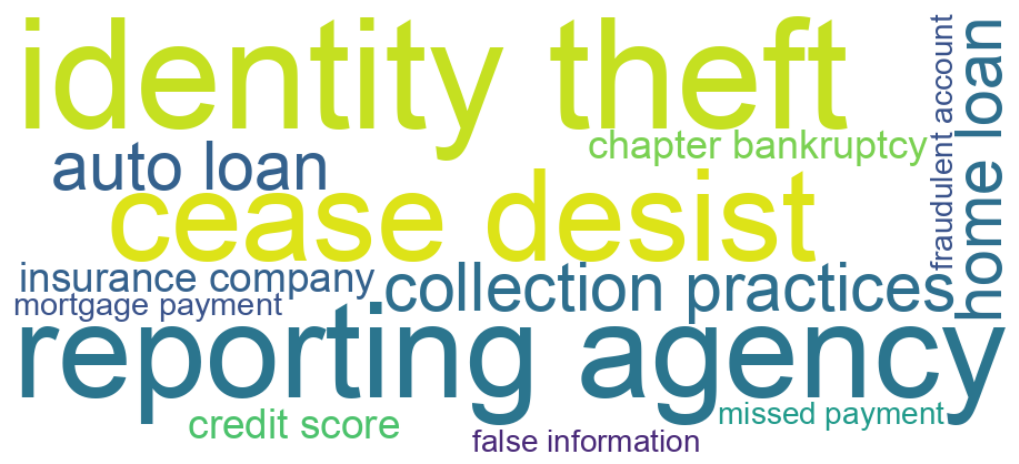

In [49]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='white')
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [54]:
df = df.drop(columns=['Issue', 'Narrative'])

In [55]:
df.to_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/complaints_final.csv')